# Aula 03 — Condicionais: `if/elif/else` e `match/case`

**Semana 2** | 50 min | Referências: McKinney (2012), *Python for Data Analysis* — Apêndice *Python Language Essentials* (`kb/01_mckinney_python_for_data_analysis/15_appendix-python-language-essentials.md`)

Aula anterior: A02 (sintaxe, tipos e variáveis) · Próxima: A04 (laços e comprehensions)

## 🎯 Objetivos de aprendizagem

Ao final desta aula você será capaz de:

- Escrever **comparações** (`==`, `!=`, `>`, `<`, `>=`, `<=`) e combiná-las com `and`, `or`, `not`;
- Traduzir uma **política de crédito** (faixas de score → categoria → taxa de juro) em `if/elif/else`;
- Classificar **categorias** (regime tributário, setor CNAE) com `match/case` (Python 3.10+);
- Usar a **expressão ternária** (`x if cond else y`) para escolhas de valor em uma linha;
- Evitar os erros clássicos: `=` vs `==`, comparação exata de `float`, ordem errada dos ramos.

In [1]:
# Setup — imports e padrões visuais usados na aula
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def brl(x):
    """Formata um número como moeda brasileira: R$ 1.234,56."""
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

np.random.seed(42)  # reprodutibilidade quando houver aleatoriedade

print(sys.version)  # match/case exige Python 3.10+

3.11.15 (main, Mar  3 2026, 15:47:15) [Clang 21.1.4 ]


> O ambiente do curso (`oikos_py`) roda **Python 3.11**, então `match/case` (introduzido no
> 3.10) está disponível. Em versões antigas, o mesmo efeito se obtém com `if/elif`.

## 1. Operadores relacionais: comparar é perguntar

**Intuição econômica.** Antes de decidir, a consultoria compara números: o score do cliente
contra a régua da política de crédito, o câmbio do dia contra a cotação fechada no contrato,
a Selic contra a taxa pactuada. Cada comparação devolve um **booleano** (`True`/`False`) — a
resposta sim/não que alimenta a decisão.

| operador | pergunta | exemplo |
|---|---|---|
| `==` | é igual a? | `cambio == 5.12` |
| `!=` | é diferente de? | `regime != "simples"` |
| `>` / `<` | maior / menor? | `score > 700` |
| `>=` / `<=` | maior/menor **ou igual**? | `score >= 700` |

Dois cuidados:
- `=` **atribui**; `==` **compara**;
- `float` raramente deve ser comparado com `==` exato (veja a célula do `0.1 + 0.2`).

In [2]:
# Comparação devolve bool e é encadeável — números reais do contexto OIKOS
score = 672                    # score de crédito (0 a 1000) de uma PME goiana
cambio = 5.12                  # R$/US$ (nível de referência set/2026)

print("score >= 700 ->", score >= 700)
print("cambio == 5.12 ->", cambio == 5.12)
print("encadeado:", 450 <= score < 700, "| equivalente:", (450 <= score) and (score < 700))

# Dado de planilha muitas vezes chega como TEXTO — converter antes de comparar
score_planilha = "672"
# print(score_planilha > 600)   # TypeError: '>' não compara str com int
print("convertido:", int(score_planilha) > 600)

score >= 700 -> False
cambio == 5.12 -> True
encadeado: True | equivalente: True
convertido: True


In [3]:
# Comparar float com == é frágil: aritmética binária acumula erro
print("0.1 + 0.2 == 0.3 ->", 0.1 + 0.2 == 0.3)   # False! (surpresa clássica)

# Em consultoria (dinheiro!), compare com margem:
valor_calculado = 0.1 + 0.2
print("com margem:", abs(valor_calculado - 0.3) < 1e-9)

0.1 + 0.2 == 0.3 -> False
com margem: True


## 2. Operadores lógicos: `and`, `or`, `not`

**Intuição econômica.** A política de crédito nunca depende de um critério só: *aprova-se
quem tem score bom **e** dívida controlada*, e *o cliente entra por esta regra **ou** por
aquela* — desde que não esteja **negativado**. `and` = exigência cumulativa; `or` = caminhos
alternativos; `not` = o inverso.

$$\text{aprovado} = \lnot\,\text{negativado} \;\wedge\; \big[(s \ge 650 \land d \le 0{,}5) \lor (s \ge 700 \land g)\big]$$

Precedência: `not` > `and` > `or`. **Em dúvida, use parênteses** — código que o orientador
lê sem ambiguidade vale mais que código curto.

In [4]:
# and / or / not com os dados da política de crédito
score = 672
divida_receita = 0.48        # dívida / receita anual
garantia = False             # ofereceu garantia real?
negativado = False           # tem pauta em bureaus de crédito?

print("score >= 650 and divida_receita <= 0.5 ->", score >= 650 and divida_receita <= 0.5)
print("score >= 700 and garantia            ->", score >= 700 and garantia)
print("not negativado                       ->", not negativado)

score >= 650 and divida_receita <= 0.5 -> True
score >= 700 and garantia            -> False
not negativado                       -> True


In [5]:
# A regra combinada da política — parênteses isolam o 'or' dentro do 'and'
aprovado = (
    not negativado
    and ((score >= 650 and divida_receita <= 0.5)
         or (score >= 700 and garantia))
)
print("APROVADO" if aprovado else "REPROVADO")

APROVADO


In [6]:
# Short-circuit e ternária: avaliação preguiçosa e valor em uma linha
score = 291
resultado = (score >= 650) and (divida_receita <= 0.5)   # 1ª já é False -> 2ª nem roda
print("short-circuit ->", resultado)

score = 672
faixa = "alta" if score >= 700 else "média/baixa"        # ternária (McKinney, Apêndice)
print(f"score {score} -> faixa {faixa}")

short-circuit -> False
score 672 -> faixa média/baixa


## 3. `if / elif / else` — classificar risco de crédito

**Intuição econômica.** A política de crédito da OIKOS converte score contínuo (0–1000) em
categorias com taxas distintas. Faixas ilustrativas de capital de giro PJ:

| categoria | score | taxa mensal | leitura |
|---|---|---|---|
| A | ≥ 700 | 1,9% | risco baixo, spread apertado |
| B | 450–699 | 3,4% | risco médio |
| C | < 450 | 6,2% | risco alto, spread compensa inadimplência |

O Python testa os ramos **de cima para baixo** e para no primeiro verdadeiro — por isso o
`elif score >= 450` não precisa de teto superior: só chega lá quem já falhou em `>= 700`.
$$\text{categoria}(s)=\begin{cases}A,& s\ge700\\ B,& 450\le s<700\\ C,& s<450\end{cases}$$

In [7]:
# if/elif/else básico — a política de crédito em três ramos
score = 672

if score >= 700:
    categoria = "A"
    taxa_mensal = 0.019
elif score >= 450:
    categoria = "B"          # já sabemos que score < 700
    taxa_mensal = 0.034
else:
    categoria = "C"
    taxa_mensal = 0.062

print(f"score {score} -> categoria {categoria} | taxa {taxa_mensal:.2%} a.m.")

score 672 -> categoria B | taxa 3.40% a.m.


In [8]:
# A ordem dos ramos importa: inverter quebra a classificação
score = 812

if score >= 450:
    categoria_errada = "B"      # 812 >= 450 é True -> para aqui!
elif score >= 700:
    categoria_errada = "A"      # nunca é alcançado

print(f"score 812 classificado como {categoria_errada} (errado!) — teste do ramo mais restritivo primeiro")

score 812 classificado como B (errado!) — teste do ramo mais restritivo primeiro


In [9]:
# Valores limite e prévia da Aula 04: bordas das faixas + carteira inteira com 'for'
for score in [700, 699, 450, 449]:
    if score >= 700:
        categoria = "A"
    elif score >= 450:
        categoria = "B"
    else:
        categoria = "C"
    print(f"score {score} -> {categoria}")

score 700 -> A
score 699 -> B
score 450 -> B
score 449 -> C


In [10]:
# Prévia da Aula 04: a mesma regra aplicada à carteira inteira com um 'for'
carteira = [
    {"cliente": "Distribuidora Araguaia",   "score": 812},
    {"cliente": "Laticínios Serra Dourada", "score": 464},
    {"cliente": "Empório Cerrado",          "score": 735},
    {"cliente": "Oficina Anhanguera",       "score": 291},
    {"cliente": "Padaria Sol Nascente",     "score": 503},
]

for c in carteira:
    score = c["score"]
    if score >= 700:
        categoria, taxa_mensal = "A", 0.019
    elif score >= 450:
        categoria, taxa_mensal = "B", 0.034
    else:
        categoria, taxa_mensal = "C", 0.062
    print(f"{c['cliente']:28s} score {score} -> {categoria} | taxa {taxa_mensal:.2%} a.m.")

Distribuidora Araguaia       score 812 -> A | taxa 1.90% a.m.
Laticínios Serra Dourada     score 464 -> B | taxa 3.40% a.m.
Empório Cerrado              score 735 -> A | taxa 1.90% a.m.
Oficina Anhanguera           score 291 -> C | taxa 6.20% a.m.
Padaria Sol Nascente         score 503 -> B | taxa 3.40% a.m.


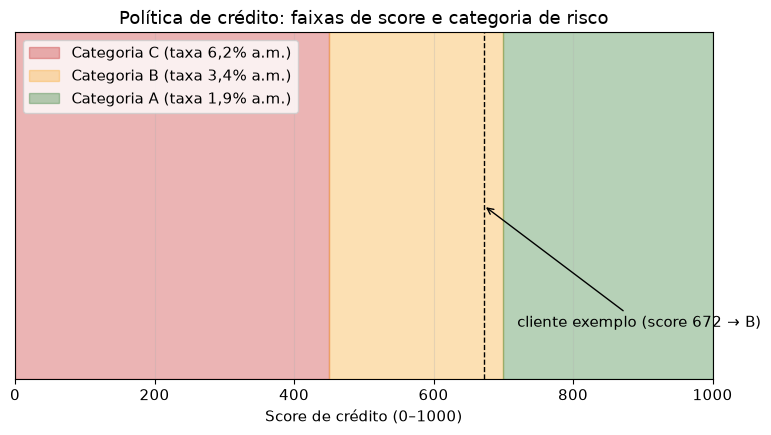

In [11]:
# Visualizar as faixas da política de crédito (score -> categoria)
fig, ax = plt.subplots()
limites = [0, 450, 700, 1000]
cores = {"A": "#2e7d32", "B": "#f9a825", "C": "#c62828"}
for i, cat in enumerate(["C", "B", "A"]):
    ax.axvspan(limites[i], limites[i + 1], color=cores[cat], alpha=0.35,
               label=f"Categoria {cat} (taxa {'1,9%' if cat == 'A' else '3,4%' if cat == 'B' else '6,2%'} a.m.)")
ax.axvline(672, color="k", linestyle="--", linewidth=1)
ax.annotate("cliente exemplo (score 672 → B)", xy=(672, 0.5), xytext=(720, 0.15),
            arrowprops=dict(arrowstyle="->"))
ax.set_yticks([])
ax.set_xlim(0, 1000)
ax.set_xlabel("Score de crédito (0–1000)")
ax.set_title("Política de crédito: faixas de score e categoria de risco")
ax.legend(loc="upper left")
plt.show()

## 4. `match/case` — regimes tributários

**Intuição econômica.** Regime tributário não é faixa numérica: é **categoria nomeada**.
Para regras de dispensa por categoria, o `match/case` (Python 3.10+) é mais legível que uma
escada de `elif` — parece a tabela de decisão que o cliente assinaria.

Cargas efetivas **ilustrativas** (comércio/serviços, para fins didáticos):

| regime | carga sobre a receita | observação |
|---|---|---|
| Simples Nacional | ~5% | anexo e faixa dependem da atividade |
| Lucro Presumido | ~8,5% | IRPJ+CSLL+PIS/COFINS sobre presunção |
| Lucro Real | ~6,5% | depende da margem real; margem baixa → carga menor |

Aqui o `match` também **desempacota tuplas** `(regime, faturamento)` e usa **guarda** (`if`)
para checar o teto legal do Simples Nacional: **R$ 4,8 milhões** de receita bruta (2026).

In [12]:
# match/case com padrões literais — categorização de regime tributário
regime = "simples"

match regime:
    case "simples":
        carga = 0.05            # alíquota efetiva típica (Anexo I, ilustrativa)
        rotulo = "Simples Nacional"
    case "presumido":
        carga = 0.085           # presunção de lucro, comércio
        rotulo = "Lucro Presumido"
    case "real":
        carga = 0.065           # depende da margem efetiva
        rotulo = "Lucro Real"
    case _:                     # coringa = o 'else' do match
        carga = None
        rotulo = "Regime não cadastrado"

print(f"{rotulo}: carga estimada {carga:.1%}" if carga else f"{rotulo} (sem estimativa)")

Simples Nacional: carga estimada 5.0%


In [13]:
# match com tuplas e guarda (if): o teto legal do Simples é R$ 4,8 mi em 2026
empresas = [
    ("Empório Cerrado",                "simples",    2_400_000),
    ("Gráfica Goiânia Moderna",        "simples",    5_100_000),   # acima do teto!
    ("Transportadora Anhanguera",      "presumido", 12_000_000),
    ("Agroindustrial Vale do Araguaia","real",      90_000_000),
]

for nome, reg, faturamento in empresas:
    match (reg, faturamento):
        case ("simples", fat) if fat <= 4_800_000:
            classificacao = f"Simples válido (receita {brl(fat)})"
        case ("simples", _):
            classificacao = f"Excede o teto do Simples ({brl(4_800_000)}) — migrar de regime"
        case ("presumido", fat) if fat <= 78_000_000:
            classificacao = f"Presumido válido (receita {brl(fat)})"
        case ("presumido", _):
            classificacao = "Excede o teto do Presumido (R$ 78 mi) — Lucro Real"
        case ("real", _):
            classificacao = "Lucro Real (obrigatório acima dos tetos)"
        case _:
            classificacao = "Regime desconhecido — revisar cadastro"
    print(f"{nome:34s} {reg:10s} {classificacao}")

Empório Cerrado                    simples    Simples válido (receita R$ 2.400.000,00)
Gráfica Goiânia Moderna            simples    Excede o teto do Simples (R$ 4.800.000,00) — migrar de regime
Transportadora Anhanguera          presumido  Presumido válido (receita R$ 12.000.000,00)
Agroindustrial Vale do Araguaia    real       Lucro Real (obrigatório acima dos tetos)


> **Leitura econômica do resultado:** a Gráfica Goiânia Moderna declara Simples, mas com
> receita de R$ 5,1 mi está **acima do teto legal** — a guarda `if fat <= 4_800_000` pega a
> inconsistência cadastral antes que ela vire passivo tributário no relatório da consultoria.

## 5. `match/case` — setores CNAE

**Intuição econômica.** Na pesquisa com clientes, a OIKOS agrupa empresas pela **seção da
CNAE** (Classificação Nacional de Atividades Econômicas): `A` agropecuária, `B–E` indústria,
`F` construção, `G` comércio, `H–N` serviços. A letra chegando da planilha é um valor
categórico — caso típico de `match` com **alternativas `|`**.

In [14]:
# match com alternativas '|' — seções CNAE (letra) -> grande setor
secao = "A"          # letra da seção CNAE do cliente

match secao:
    case "A":
        setor = "Agropecuária / extração vegetal"
    case "B" | "C" | "D" | "E":
        setor = "Indústria e extração mineral"
    case "F":
        setor = "Construção"
    case "G":
        setor = "Comércio"
    case "H" | "I" | "J" | "K" | "L" | "M" | "N":
        setor = "Serviços"
    case _:
        setor = "Seção inválida"

print(f"Seção {secao} -> {setor}")

Seção A -> Agropecuária / extração vegetal


Seção A: Agropecuária
Seção G: Comércio
Seção J: Serviços
Seção F: Construção
Seção X: Seção inválida — revisar cadastro


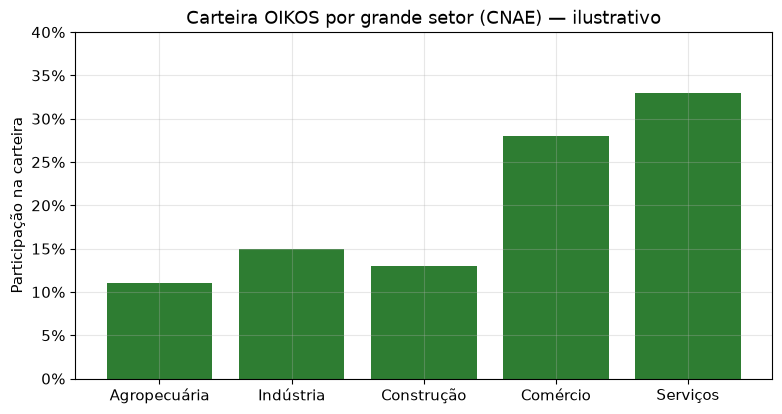

In [15]:
# O 'match' de CNAE dentro de um laço + participação setorial da carteira OIKOS
secoes_clientes = ["A", "G", "J", "F", "X"]   # X = dado sujo de propósito

for secao in secoes_clientes:
    match secao:
        case "A":
            setor = "Agropecuária"
        case "B" | "C" | "D" | "E":
            setor = "Indústria"
        case "F":
            setor = "Construção"
        case "G":
            setor = "Comércio"
        case "H" | "I" | "J" | "K" | "L" | "M" | "N":
            setor = "Serviços"
        case _:
            setor = "Seção inválida — revisar cadastro"
    print(f"Seção {secao}: {setor}")

# Onde os setores aparecem na prática: participação estimada das PMEs goianas por setor
setores = ["Agropecuária", "Indústria", "Construção", "Comércio", "Serviços"]
participacao = [0.11, 0.15, 0.13, 0.28, 0.33]   # ilustrativo — carteira de clientes OIKOS

fig, ax = plt.subplots()
ax.bar(setores, participacao, color="#2e7d32")
ax.set_ylim(0, 0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylabel("Participação na carteira")
ax.set_title("Carteira OIKOS por grande setor (CNAE) — ilustrativo")
plt.show()

> **Para o projeto da disciplina:** quando a tabela de categorias cresce (todas as seções
> CNAE, todos os regimes), o `dict` costuma ser melhor que o `match` — veremos na **Aula 04**
> com *dict comprehension*.

## 📝 Exercícios

Tente resolver antes de abrir a célula de solução. Contexto: carteira de clientes PME da
OIKOS, política de crédito e cadastro tributário de Goiás.

### Exercício 1 — Classificar a carteira por score

A lista abaixo traz os scores de cinco clientes. Para cada um, determine a **categoria**
(A: ≥ 700; B: 450–699; C: < 450) e a **taxa mensal** da categoria (A: 1,9%; B: 3,4%; C: 6,2%).
Imprima uma linha por cliente no formato `Cliente i: score S → categoria C | taxa T a.m.`

*Dica: um `for` simples já resolve — ele é o tema da Aula 04, mas aqui é só repetir o `if`.*

In [16]:
# EXERCÍCIO 1 — seu código aqui
scores = [812, 464, 735, 291, 503]


In [17]:
# SOLUÇÃO 1
scores = [812, 464, 735, 291, 503]

for i, score in enumerate(scores, start=1):   # enumerate: detalhes na Aula 04
    if score >= 700:
        categoria = "A"
        taxa_mensal = 0.019
    elif score >= 450:
        categoria = "B"
        taxa_mensal = 0.034
    else:
        categoria = "C"
        taxa_mensal = 0.062
    print(f"Cliente {i}: score {score} → categoria {categoria} | taxa {taxa_mensal:.2%} a.m.")

Cliente 1: score 812 → categoria A | taxa 1.90% a.m.
Cliente 2: score 464 → categoria B | taxa 3.40% a.m.
Cliente 3: score 735 → categoria A | taxa 1.90% a.m.
Cliente 4: score 291 → categoria C | taxa 6.20% a.m.
Cliente 5: score 503 → categoria B | taxa 3.40% a.m.


### Exercício 2 — Regra combinada de aprovação

Para cada cliente do dicionário abaixo, aplique a política combinada da Seção 2 (fórmula da
apostila): **não negativado** E ((score ≥ 650 E dívida/receita ≤ 0,5) OU (score ≥ 700 E
garantia)). Imprima `nome: APROVADO` ou `nome: REPROVADO`.

In [18]:
# EXERCÍCIO 2 — seu código aqui
clientes = [
    {"nome": "Distribuidora Araguaia",     "score": 672, "divida_receita": 0.48, "garantia": False, "negativado": False},
    {"nome": "Laticínios Serra Dourada",   "score": 715, "divida_receita": 0.75, "garantia": True,  "negativado": False},
]


In [19]:
# SOLUÇÃO 2
clientes = [
    {"nome": "Distribuidora Araguaia",     "score": 672, "divida_receita": 0.48, "garantia": False, "negativado": False},
    {"nome": "Laticínios Serra Dourada",   "score": 715, "divida_receita": 0.75, "garantia": True,  "negativado": False},
]

for c in clientes:
    aprovado = (
        not c["negativado"]
        and ((c["score"] >= 650 and c["divida_receita"] <= 0.5)
             or (c["score"] >= 700 and c["garantia"]))
    )
    print(f"{c['nome']}: {'APROVADO' if aprovado else 'REPROVADO'}")

Distribuidora Araguaia: APROVADO
Laticínios Serra Dourada: APROVADO


### Exercício 3 — Carga tributária estimada por regime

Com `match/case`, estime a carga tributária sobre a receita (ilustrativa): Simples → 5%;
Presumido → 8,5%; Real → 6,5%; qualquer outro valor → imprimir `regime não cadastrado`.
Imprima uma linha por empresa.

In [20]:
# EXERCÍCIO 3 — seu código aqui
empresas = [
    {"nome": "Empório Cerrado",                  "regime": "simples",   "faturamento": 2_400_000},
    {"nome": "Transportadora Anhanguera",        "regime": "presumido", "faturamento": 12_000_000},
    {"nome": "Agroindustrial Vale do Araguaia",  "regime": "real",      "faturamento": 90_000_000},
]


In [21]:
# SOLUÇÃO 3
empresas = [
    {"nome": "Empório Cerrado",                  "regime": "simples",   "faturamento": 2_400_000},
    {"nome": "Transportadora Anhanguera",        "regime": "presumido", "faturamento": 12_000_000},
    {"nome": "Agroindustrial Vale do Araguaia",  "regime": "real",      "faturamento": 90_000_000},
]

for e in empresas:
    match e["regime"]:
        case "simples":
            carga = 0.05          # alíquota efetiva típica (Anexo I, ilustrativa)
        case "presumido":
            carga = 0.085         # IRPJ+CSLL+PIS/COFINS presunção, comércio
        case "real":
            carga = 0.065         # depende da margem; margem baixa → carga menor
        case _:
            carga = None
    print(f"{e['nome']}: carga estimada {carga:.1%}" if carga else f"{e['nome']}: regime não cadastrado")

Empório Cerrado: carga estimada 5.0%
Transportadora Anhanguera: carga estimada 8.5%
Agroindustrial Vale do Araguaia: carga estimada 6.5%


### Exercício 4 — Setores CNAE com `match`

Classifique cada letra de seção da lista abaixo em um **grande setor** (mesma tabela da
Seção 5) usando `match/case` com alternativas `|`. A seção `"X"` não existe — o código deve
imprimir `Seção X: Seção inválida` **sem quebrar**.

In [22]:
# EXERCÍCIO 4 — seu código aqui
secoes = ["A", "G", "J", "F", "X"]


In [23]:
# SOLUÇÃO 4
secoes = ["A", "G", "J", "F", "X"]

for secao in secoes:
    match secao:
        case "A":
            setor = "Agropecuária / extração vegetal"
        case "B" | "C" | "D" | "E":
            setor = "Indústria e extração mineral"
        case "F":
            setor = "Construção"
        case "G":
            setor = "Comércio"
        case "H" | "I" | "J" | "K" | "L" | "M" | "N":
            setor = "Serviços"
        case _:
            setor = "Seção inválida"
    print(f"Seção {secao}: {setor}")

Seção A: Agropecuária / extração vegetal
Seção G: Comércio
Seção J: Serviços
Seção F: Construção
Seção X: Seção inválida


## 📌 Resumo & para casa

- Comparação devolve **bool**; `=` atribui, `==` compara; `float` compara-se com margem, não com `==`.
- `and`/`or`/`not` combinam condições; precedência `not` > `and` > `or` — parênteses deixam a política explícita.
- `if/elif/else`: os ramos são testados **em ordem** — comece pelo caso mais restritivo; `else` é o coringa.
- Expressão ternária `x if cond else y` para escolher valores em uma linha.
- `match/case` (3.10+) brilha em **categorias nomeadas**: regimes tributários, seções CNAE; `|` agrupa padrões e `case _` captura o resto — sempre por último.
- Guardas (`case x if cond`) codificam **limites legais** dentro do padrão (teto do Simples: R$ 4,8 mi em 2026).

**Para casa:** refaça os Exercícios 1 e 3 trocando as faixas/regimes pela política de uma
empresa real que você conheça (invente os números, mas mantenha realistas).

**Próxima aula (A04):** `for`/`while` e comprehensions — as mesmas regras de decisão dentro
de laços, processando a carteira inteira sem copiar-e-colar `if`s.

**Referências (KB):**
- `kb/01_mckinney_python_for_data_analysis/15_appendix-python-language-essentials.md` — seções *The Basics* (condicionais, ternárias) e *Data Structures and Sequences*.